# 模块六：无监督学习
**案例背景**：聚类、降维与异常检测。本 Notebook 涵盖 K-Means 聚类、PCA 降维与孤立森林异常检测。

# 无监督学习（Unsupervised）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---

## K-Means



来源: 面经知识库 04-unsupervised-learning.md §1.4 K-Means


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs



## 1. 模拟生成 3 个簇的数据


In [2]:
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)



## 2. 模型训练


In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
kmeans.fit(X)

y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_



## 3. 可视化


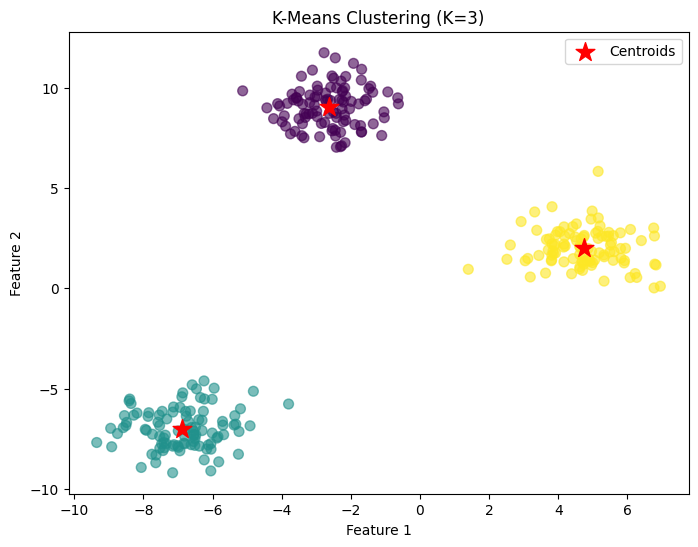

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap="viridis", alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="*", label="Centroids")

plt.title("K-Means Clustering (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


---

## PCA



来源: 面经知识库 04-unsupervised-learning.md §2.4 PCA


In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



## 1. 模拟生成三维数据


In [6]:
np.random.seed(42)
n_samples = 200
x1 = np.random.normal(0, 10, n_samples)
x2 = x1 * 0.8 + np.random.normal(0, 2, n_samples)
x3 = np.random.normal(0, 5, n_samples)

X = np.column_stack((x1, x2, x3))



## 2. 数据标准化 (PCA 必须步骤)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 3. PCA 模型训练与降维


In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("--- PCA 降维结果 ---")
print(f"各主成分的方差贡献率: {pca.explained_variance_ratio_}")
print(f"累积方差贡献率: {np.sum(pca.explained_variance_ratio_):.2f}")



--- PCA 降维结果 ---
各主成分的方差贡献率: [0.66816636 0.32131559]
累积方差贡献率: 0.99


## 5. 可视化降维后的二维数据


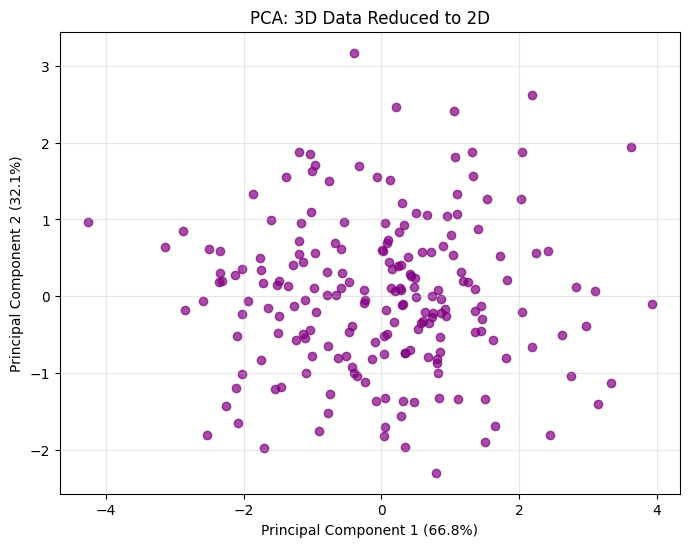

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, color="purple")
plt.title("PCA: 3D Data Reduced to 2D")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, alpha=0.3)
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


---

## 孤立森林（Isolation Forest）

基于随机树的**无监督异常检测**：思想是异常点更容易在少量随机切分下被“隔离”（路径更短）。`sklearn.ensemble.IsolationForest` 通过多棵树的平均路径长度估计异常程度。

### 1. 构造数据：稠密簇（正常）+ 均匀散布的离群点

In [10]:
import numpy as np
from sklearn.datasets import make_blobs

rng = np.random.RandomState(42)
X_inliers, _ = make_blobs(n_samples=300, centers=1, cluster_std=1.0, random_state=42)
outliers = rng.uniform(low=-9, high=9, size=(20, 2))
X_iso = np.vstack([X_inliers, outliers])

### 2. 训练并预测（`contamination` 可与真实离群比例大致对齐）

In [11]:
from sklearn.ensemble import IsolationForest

contamination = 20 / len(X_iso)
iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_iso)
y_iso = iso.predict(X_iso)  # 1 视为正常，-1 视为异常
scores_iso = iso.score_samples(X_iso)  # 数值越大越接近正常（与论文定义相反的一侧已对齐为 sklearn 约定）

### 3. 可视化：离散标签 vs 连续异常分数

C:\Users\prong\AppData\Local\Temp\ipykernel_33144\4263908076.py:49: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\prong\AppData\Local\Temp\ipykernel_33144\4263908076.py:49: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\prong\AppData\Local\Temp\ipykernel_33144\4263908076.py:49: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\prong\AppData\Local\Temp\ipykernel_33144\4263908076.py:49: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\prong\AppData\Local\Temp\ipykernel_33144\4263908076.py:49: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\prong\AppData\Local\Temp\ipykernel_33144\4263908076.py:49: UserWarning: Glyph 31614 (\

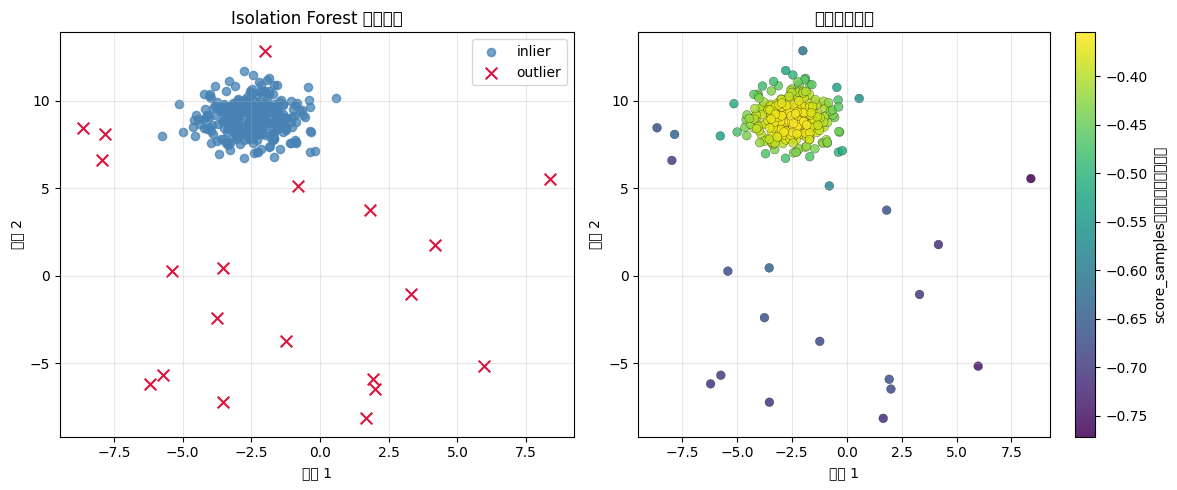

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
normal_mask = y_iso == 1
ax.scatter(
    X_iso[normal_mask, 0],
    X_iso[normal_mask, 1],
    c="steelblue",
    s=35,
    alpha=0.75,
    label="inlier",
)
ax.scatter(
    X_iso[~normal_mask, 0],
    X_iso[~normal_mask, 1],
    c="crimson",
    s=70,
    marker="x",
    linewidths=1.5,
    label="outlier",
)
ax.set_title("Isolation Forest 预测标签")
ax.set_xlabel("特征 1")
ax.set_ylabel("特征 2")
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
sc = ax2.scatter(
    X_iso[:, 0],
    X_iso[:, 1],
    c=scores_iso,
    cmap="viridis",
    s=40,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
cb = plt.colorbar(sc, ax=ax2)
cb.set_label("score_samples（越大越像正常点）")
ax2.set_title("连续异常分数")
ax2.set_xlabel("特征 1")
ax2.set_ylabel("特征 2")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()